## Experiment 6 

### Inlab

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# Load raw Iris dataset
raw_iris = load_iris()
features = raw_iris.feature_names
X_raw = raw_iris.data
y_true = raw_iris.target

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Store in a DataFrame for visualization
iris_df = pd.DataFrame(data=X_scaled, columns=features)
iris_df['species_id'] = y_true
species_map = {i: name for i, name in enumerate(raw_iris.target_names)}
iris_df['species_name'] = iris_df['species_id'].map(species_map)

print("Standardized dataset dimensions:", X_scaled.shape)
print("\nFirst 3 rows of standardized dataset:(24EU02022)")
print(iris_df.head(3))


Standardized dataset dimensions: (150, 4)

First 3 rows of standardized dataset:(24EU02022)
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0          -0.900681          1.019004          -1.340227         -1.315444   
1          -1.143017         -0.131979          -1.340227         -1.315444   
2          -1.385353          0.328414          -1.397064         -1.315444   

   species_id species_name  
0           0       setosa  
1           0       setosa  
2           0       setosa  


### Subtask 1.2

In [2]:
# Calculate the covariance matrix
cov_matrix = np.cov(X_scaled.T)
print("Covariance Matrix:(24EU02022)\n", cov_matrix)

# Perform eigenvalue decomposition
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print("\nEigenvalues (Variance components):(24EU02022)\n", eigenvalues)
print("\nEigenvectors (Principal Axes):(24EU02022)\n", eigenvectors)


Covariance Matrix:(24EU02022)
 [[ 1.00671141 -0.11835884  0.87760447  0.82343066]
 [-0.11835884  1.00671141 -0.43131554 -0.36858315]
 [ 0.87760447 -0.43131554  1.00671141  0.96932762]
 [ 0.82343066 -0.36858315  0.96932762  1.00671141]]

Eigenvalues (Variance components):(24EU02022)
 [2.93808505 0.9201649  0.14774182 0.02085386]

Eigenvectors (Principal Axes):(24EU02022)
 [[ 0.52106591 -0.37741762 -0.71956635  0.26128628]
 [-0.26934744 -0.92329566  0.24438178 -0.12350962]
 [ 0.5804131  -0.02449161  0.14212637 -0.80144925]
 [ 0.56485654 -0.06694199  0.63427274  0.52359713]]


### Subtask 1.3

In [4]:
from sklearn.decomposition import PCA

# Initialize PCA to extract 2 orthogonal components
pca_model = PCA(n_components=2, random_state=42)
X_pca = pca_model.fit_transform(X_scaled)

# Convert to a DataFrame
pca_df = pd.DataFrame(data=X_pca, columns=['PC_1', 'PC2'])
pca_df['species_name'] = iris_df['species_name']

print("Transformed PCA space dimensions:(24EU02022)", X_pca.shape)
print("\nFirst 3 projected coordinates:(24EU02022)")
print(pca_df.head(3))

Transformed PCA space dimensions:(24EU02022) (150, 2)

First 3 projected coordinates:(24EU02022)
       PC_1       PC2 species_name
0 -2.264703  0.480027       setosa
1 -2.080961 -0.674134       setosa
2 -2.364229 -0.341908       setosa


### Subtask 1.4

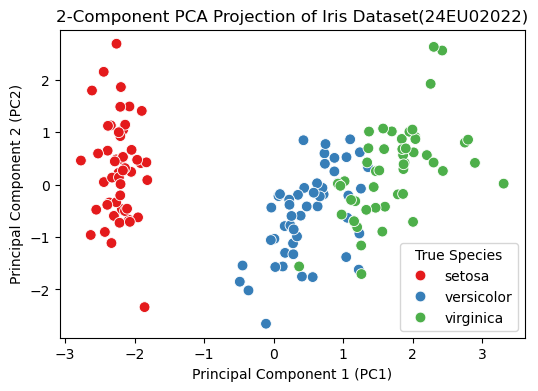

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.scatterplot(data=pca_df, x='PC_1', y='PC2', hue='species_name', palette='Set1', s=60)
plt.title("2-Component PCA Projection of Iris Dataset(24EU02022)")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.legend(title='True Species')
plt.show()


### Subtask 1.5

In [6]:
explained_variance = pca_model.explained_variance_ratio_
cumulative_variance = np.sum(explained_variance)

print("Explained Variance per Component:(24EU02022)")
for i, var in enumerate(explained_variance):
    print(f"  PC{i+1}: {var*100:.2f}%")

print(f"\nTotal Cumulative Variance Retained by 2 Components:(24EU02022) {cumulative_variance*100:.2f}%")


Explained Variance per Component:(24EU02022)
  PC1: 72.96%
  PC2: 22.85%

Total Cumulative Variance Retained by 2 Components:(24EU02022) 95.81%


Dataset Shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']

CLASSIFICATION WITHOUT PCA(24EU02022)
Accuracy without PCA:(24EU02022) 0.9333333333333333

Classification Report:(24EU02022)
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


CLASSIFICATION WITH PCA(24EU02022)
Explained Variance Ratio: [0.72677234 0.23066667]
Total Explained Variance: 0.9574390106545365
Accuracy with PCA: 0.9

Classification Report:(24EU02022)
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90

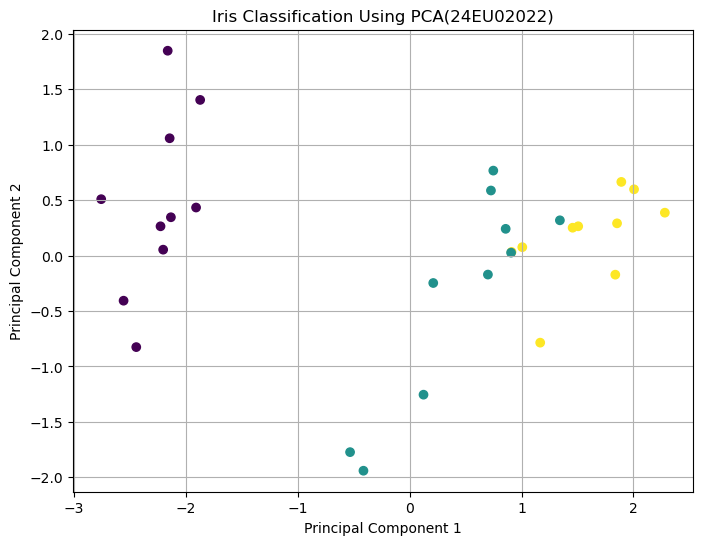

In [7]:
# ============================================================
# Classification with and without PCA
# Dataset: Iris Dataset
# Classifier: Logistic Regression
# ============================================================

# Step 1: Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# ============================================================
# Step 2: Load the Dataset
# ============================================================

iris = load_iris()

X = iris.data                 # Input features
y = iris.target               # Target labels
feature_names = iris.feature_names
target_names = iris.target_names

print("Dataset Shape:", X.shape)
print("Features:", feature_names)
print("Classes:", target_names)


# ============================================================
# Step 3: Split the Dataset
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# ============================================================
# Step 4: Feature Scaling
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ============================================================
# PART A: CLASSIFICATION WITHOUT PCA
# ============================================================

print("\n========================================")
print("CLASSIFICATION WITHOUT PCA(24EU02022)")
print("========================================")

# Create Logistic Regression model
model_without_pca = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Train the model
model_without_pca.fit(
    X_train_scaled,
    y_train
)

# Predict test data
y_pred_without_pca = model_without_pca.predict(
    X_test_scaled
)

# Calculate accuracy
accuracy_without_pca = accuracy_score(
    y_test,
    y_pred_without_pca
)

print("Accuracy without PCA:(24EU02022)",
      accuracy_without_pca)

print("\nClassification Report:(24EU02022)")
print(
    classification_report(
        y_test,
        y_pred_without_pca,
        target_names=target_names
    )
)


# ============================================================
# PART B: CLASSIFICATION WITH PCA
# ============================================================

print("\n========================================")
print("CLASSIFICATION WITH PCA(24EU02022)")
print("========================================")

# Apply PCA
pca = PCA(
    n_components=2
)

# Fit PCA only on training data
X_train_pca = pca.fit_transform(
    X_train_scaled
)

# Transform test data using the same PCA
X_test_pca = pca.transform(
    X_test_scaled
)

# Display explained variance
print("Explained Variance Ratio:",
      pca.explained_variance_ratio_)

print("Total Explained Variance:",
      pca.explained_variance_ratio_.sum())


# Create Logistic Regression model
model_with_pca = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Train the model using PCA features
model_with_pca.fit(
    X_train_pca,
    y_train
)

# Predict test data
y_pred_with_pca = model_with_pca.predict(
    X_test_pca
)

# Calculate accuracy
accuracy_with_pca = accuracy_score(
    y_test,
    y_pred_with_pca
)

print("Accuracy with PCA:",
      accuracy_with_pca)

print("\nClassification Report:(24EU02022)")
print(
    classification_report(
        y_test,
        y_pred_with_pca,
        target_names=target_names
    )
)


# ============================================================
# PART C: COMPARE BOTH MODELS
# ============================================================

print("\n========================================")
print("COMPARISON")
print("========================================")

comparison = pd.DataFrame({
    "Method": [
        "Without PCA",
        "With PCA"
    ],
    "Number of Features": [
        X_train_scaled.shape[1],
        X_train_pca.shape[1]
    ],
    "Accuracy": [
        accuracy_without_pca,
        accuracy_with_pca
    ]
})

print(comparison)


# ============================================================
# PART D: VISUALIZE PCA FEATURES
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    X_test_pca[:, 0],
    X_test_pca[:, 1],
    c=y_test
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Iris Classification Using PCA(24EU02022)")
plt.grid()

plt.show()

### Subtask 2.1

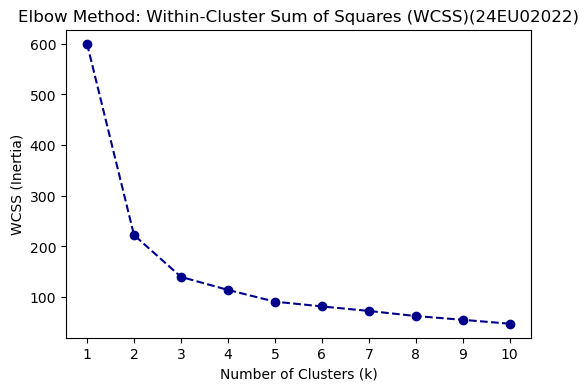

In [8]:
import warnings
warnings.filterwarnings("ignore")

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
k_range = range(1, 11)

# Fit K-Means iteratively
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(6, 4))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='darkblue')
plt.title("Elbow Method: Within-Cluster Sum of Squares (WCSS)(24EU02022)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.xticks(k_range)
plt.show()


### Subtask 2.2


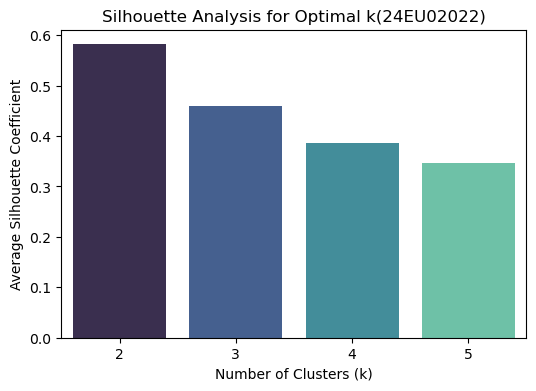

k = 2 yielded the highest silhouette coefficient (0.5818).


In [9]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
k_eval = range(2, 6)

# Calculate silhouette scores for different cluster counts
for k in k_eval:
    kmeans_temp = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels_temp)
    silhouette_scores.append(score)

# Plot Silhouette scores
plt.figure(figsize=(6, 4))
sns.barplot(x=list(k_eval), y=silhouette_scores, palette='mako')
plt.title("Silhouette Analysis for Optimal k(24EU02022)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Average Silhouette Coefficient")
plt.show()

# Find and print the best k
best_k = k_eval[np.argmax(silhouette_scores)]
print(f"k = {best_k} yielded the highest silhouette coefficient ({max(silhouette_scores):.4f}).")


### Subtask 2.3


In [10]:
# Train K-Means on the standardized raw 4D feature space
kmeans_raw = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
kmeans_raw_labels = kmeans_raw.fit_predict(X_scaled)

# Append cluster labels to main DataFrame
iris_df['cluster_raw'] = kmeans_raw_labels
print("K-Means clustering complete. First 5 sample allocations:(24EU02022)")
print(iris_df[['species_name', 'cluster_raw']].head(5))


K-Means clustering complete. First 5 sample allocations:(24EU02022)
  species_name  cluster_raw
0       setosa            1
1       setosa            1
2       setosa            1
3       setosa            1
4       setosa            1


### Subtask 2.4

In [11]:
# Extract raw centroid coordinates in standardized space
raw_centroids_scaled = kmeans_raw.cluster_centers_

# Inverse transform centroids back to original physical measurements (cm)
raw_centroids_physical = scaler.inverse_transform(raw_centroids_scaled)

# Store in a summary table
centroids_df = pd.DataFrame(data=raw_centroids_physical, columns=features)
centroids_df.index = [f"Cluster_{i}" for i in range(3)]

print("--- Estimated Cluster Centroids (Original Physical Units - cm)(24EU02022) ---")
print(centroids_df)


--- Estimated Cluster Centroids (Original Physical Units - cm)(24EU02022) ---
           sepal length (cm)  sepal width (cm)  petal length (cm)  \
Cluster_0           5.799612          2.653772           4.382414   
Cluster_1           4.992043          3.429444           1.471740   
Cluster_2           6.792945          3.087827           5.524364   

           petal width (cm)  
Cluster_0          1.418814  
Cluster_1          0.251935  
Cluster_2          1.977790  


### Subtask 2.5


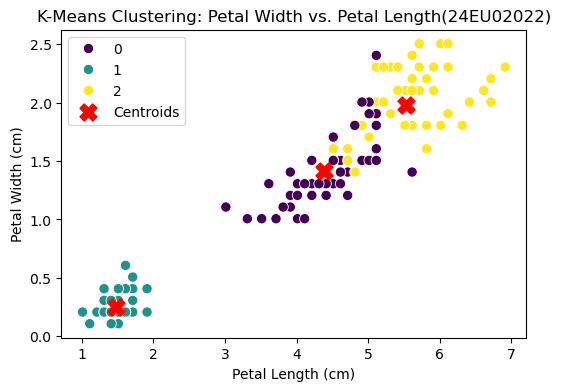

In [12]:
plt.figure(figsize=(6, 4))

# Convert standardized centroids to original units for plotting
raw_data = scaler.inverse_transform(X_scaled)

# Plot the continuous data points colored by cluster assignment
sns.scatterplot(x=raw_data[:, 2], y=raw_data[:, 3], hue=kmeans_raw_labels, palette='viridis', s=55, legend='full')

# Plot the calculated centroids on the same canvas
plt.scatter(
    raw_centroids_physical[:, 2], 
    raw_centroids_physical[:, 3], 
    color='red', 
    marker='X', 
    s=150, 
    label='Centroids'
)

plt.title("K-Means Clustering: Petal Width vs. Petal Length(24EU02022)")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.legend()
plt.show()


### Subtask 3.1


In [13]:
import warnings
warnings.filterwarnings("ignore")

from sklearn.cluster import KMeans

# Train a separate K-Means model on the 2-Component PCA space
kmeans_pca = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
kmeans_pca_labels = kmeans_pca.fit_predict(X_pca)

# Append to main DataFrame
iris_df['cluster_pca'] = kmeans_pca_labels
print("PCA space K-Means clustering completed successfully.(24EU02022)")


PCA space K-Means clustering completed successfully.(24EU02022)


### Subtask 3.2

In [14]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score

# Compute internal metrics for raw space clusters
sil_raw = silhouette_score(X_scaled, kmeans_raw_labels)
ch_raw = calinski_harabasz_score(X_scaled, kmeans_raw_labels)

# Compute internal metrics for PCA-reduced space clusters
sil_pca = silhouette_score(X_pca, kmeans_pca_labels)
ch_pca = calinski_harabasz_score(X_pca, kmeans_pca_labels)

print("--- Internal Validation (Unsupervised Quality Metrics)(24EU02022) ---")
print(f"Raw 4D Feature Space  -> Silhouette Score: {sil_raw:.4f} | Calinski-Harabasz: {ch_raw:.2f}")
print(f"PCA 2D Reduced Space -> Silhouette Score: {sil_pca:.4f} | Calinski-Harabasz: {ch_pca:.2f}")


--- Internal Validation (Unsupervised Quality Metrics)(24EU02022) ---
Raw 4D Feature Space  -> Silhouette Score: 0.4599 | Calinski-Harabasz: 241.90
PCA 2D Reduced Space -> Silhouette Score: 0.5092 | Calinski-Harabasz: 293.86


### Subtask 3.3

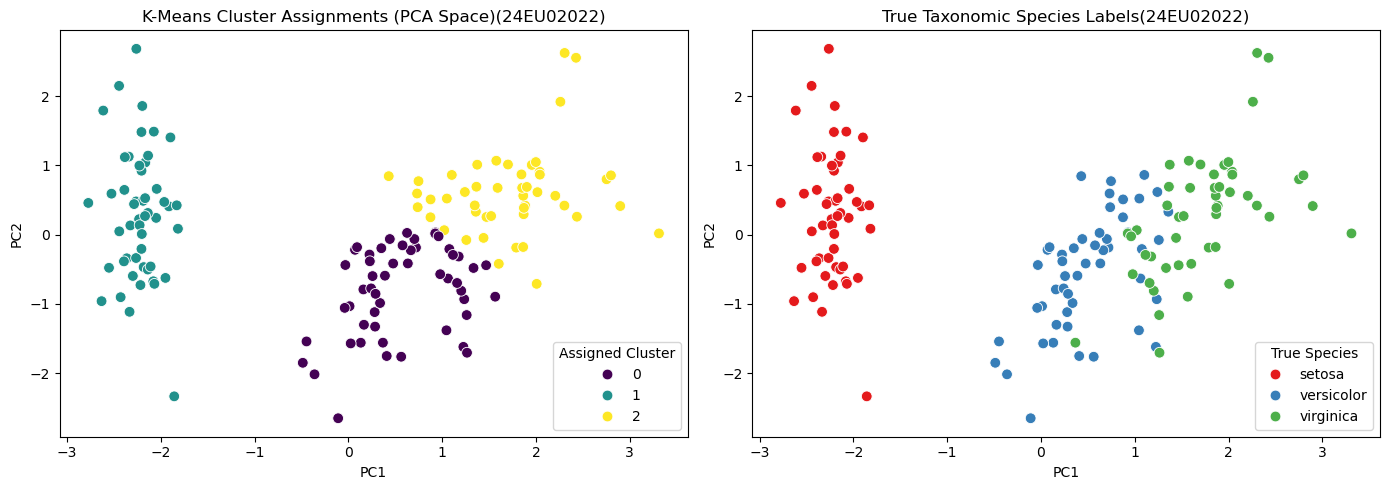

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: PCA Coordinates colored by K-Means cluster allocations
sns.scatterplot(
    data=pca_df, x='PC_1', y='PC2', hue=kmeans_pca_labels, 
    palette='viridis', s=60, ax=axes[0]
)
axes[0].set_title("K-Means Cluster Assignments (PCA Space)(24EU02022)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend(title='Assigned Cluster')

# Plot 2: PCA Coordinates colored by true species labels
sns.scatterplot(
    data=pca_df, x='PC_1', y='PC2', hue='species_name', 
    palette='Set1', s=60, ax=axes[1]
)
axes[1].set_title("True Taxonomic Species Labels(24EU02022)")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].legend(title='True Species')

plt.tight_layout()
plt.show()
